# RFC 05 — Evaluation

Evaluate saved validation predictions without retraining the classifier.

In [2]:
# Import libraries
from pathlib import Path
import sys

In [3]:
# Define the root directory of the project and config file
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS_DIR = PROJECT_ROOT / "reports" / "modeling" / "peak_risk" / "random_forest"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "modeling" / "peak_risk" / "random_forest"

REPORTS_DIR, OUTPUTS_DIR

(WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/reports/modeling/peak_risk/random_forest'),
 WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/outputs/modeling/peak_risk/random_forest'))

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
)


In [6]:
global_metrics = pd.read_csv(REPORTS_DIR / "RFC_05_global_metrics.csv")
fold_metrics = pd.read_csv(REPORTS_DIR / "RFC_05_fold_metrics.csv")
fsa_metrics = pd.read_csv(REPORTS_DIR / "RFC_05_fsa_metrics.csv")
horizon_metrics = pd.read_csv(REPORTS_DIR / "RFC_05_horizon_metrics.csv")
class_balance = pd.read_csv(REPORTS_DIR / "RFC_05_class_balance.csv")
threshold_analysis = pd.read_csv(REPORTS_DIR / "RFC_05_threshold_analysis.csv")
feature_importance = pd.read_csv(REPORTS_DIR / "RFC_06_feature_importance.csv")

predictions = pd.read_parquet(
    OUTPUTS_DIR / "random_forest_classifier_validation_predictions.parquet"
)
predictions["forecast_origin"] = pd.to_datetime(predictions["forecast_origin"])
predictions["target_timestamp"] = pd.to_datetime(predictions["target_timestamp"])






In [7]:
display(global_metrics)

,model,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,random_forest_classifier,0.669067,0.355315,0.464143,0.670551,2519424,7.482544,3.973686,0.04464,0.579137,0.941053


In [8]:
display(fold_metrics)

,fold,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,fold_2023,0.759171,0.233303,0.356919,0.612094,1257984,10.965243,3.369757,0.066639,0.628399,0.933096
1,fold_2024,0.602897,0.688093,0.642684,0.834581,1261440,4.009386,4.575961,0.022701,0.672704,0.979909


In [9]:
display(fsa_metrics)

,fold,fsa,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,fold_2023,L4T,0.474211,0.463855,0.468976,0.726947,209664,1.900183,1.858688,0.015421,0.466126,0.977690
1,fold_2023,M5R,0.515641,0.602955,0.555891,0.795790,209664,1.968864,2.302255,0.014338,0.569830,0.971411
2,fold_2023,M5S,0.453748,0.656099,0.536477,0.821711,209664,1.579670,2.284131,0.013774,0.569764,0.980085
3,fold_2023,M6G,0.808127,0.360712,0.498787,0.677828,209664,5.574634,2.488267,0.031244,0.643604,0.953548
4,fold_2023,M9R,0.591369,0.406068,0.481506,0.698150,209664,3.363954,2.309886,0.022867,0.524217,0.947074
5,fold_2023,M9W,0.987990,0.172506,0.293726,0.585144,209664,51.404151,8.975313,0.302187,0.927679,0.925991
6,fold_2024,L4T,0.645703,0.719388,0.680557,0.854015,210240,2.796804,3.115963,0.015541,0.713810,0.989099
7,fold_2024,M5R,0.497872,0.663265,0.568789,0.825924,210240,1.678082,2.235540,0.013217,0.570459,0.987831
8,fold_2024,M5S,0.452777,0.676471,0.542468,0.832606,210240,1.358447,2.029585,0.011691,0.542389,0.988892
9,fold_2024,M6G,0.599935,0.723746,0.656050,0.852753,210240,3.641553,4.393075,0.021387,0.706797,0.980595


In [10]:

display(horizon_metrics)

,fold,horizon,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,fold_2023,1,0.830518,0.248302,0.382306,0.621034,52416,10.956578,3.275717,0.065541,0.696115,0.942515
1,fold_2023,2,0.827869,0.246213,0.379546,0.619957,52416,10.956578,3.258547,0.064824,0.699657,0.946432
2,fold_2023,3,0.807834,0.229845,0.357869,0.611559,52416,10.956578,3.117369,0.065235,0.699728,0.949325
3,fold_2023,4,0.806226,0.220965,0.346863,0.607215,52416,10.956578,3.002900,0.065370,0.693846,0.946164
4,fold_2023,5,0.810961,0.229323,0.357540,0.611372,52416,10.956578,3.098291,0.063884,0.701996,0.951635
5,fold_2023,6,0.820904,0.243427,0.375504,0.618446,52416,10.956578,3.249008,0.064380,0.689786,0.946461
6,fold_2023,7,0.813731,0.237332,0.367484,0.615324,52416,10.956578,3.195589,0.064355,0.683661,0.943658
7,fold_2023,8,0.816826,0.238377,0.369052,0.615900,52416,10.956578,3.197497,0.063719,0.685172,0.943542
8,fold_2023,9,0.789700,0.224273,0.349336,0.608462,52416,10.956578,3.111645,0.065446,0.655101,0.939049
9,fold_2023,10,0.786596,0.232979,0.359484,0.612601,52416,10.956578,3.245192,0.065369,0.646292,0.935748


## Precision-Recall Curve

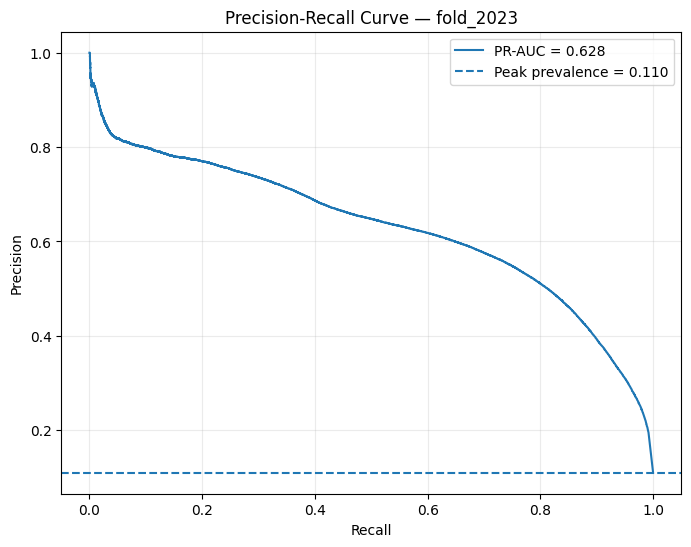

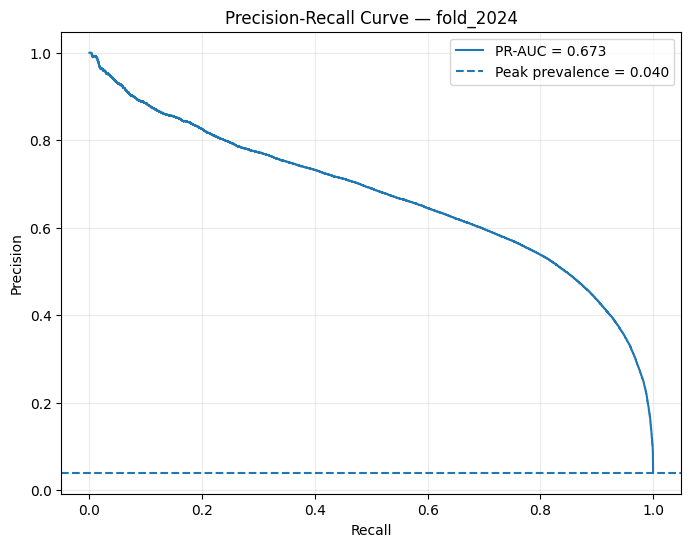

In [11]:
# Precision-Recall curve by validation fold.
for fold, group in predictions.groupby("fold", observed=True):
    precision, recall, _ = precision_recall_curve(
        group["actual"],
        group["probability"],
    )

    pr_auc = average_precision_score(
        group["actual"],
        group["probability"],
    )

    prevalence = group["actual"].mean()

    plt.figure(figsize=(8, 6))
    plt.plot(
        recall,
        precision,
        label=f"PR-AUC = {pr_auc:.3f}",
    )
    plt.axhline(
        prevalence,
        linestyle="--",
        label=f"Peak prevalence = {prevalence:.3f}",
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {fold}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## ROC Curve

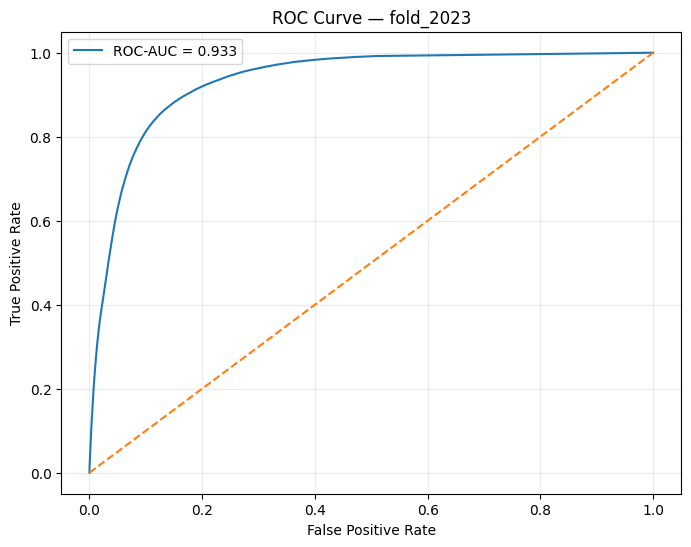

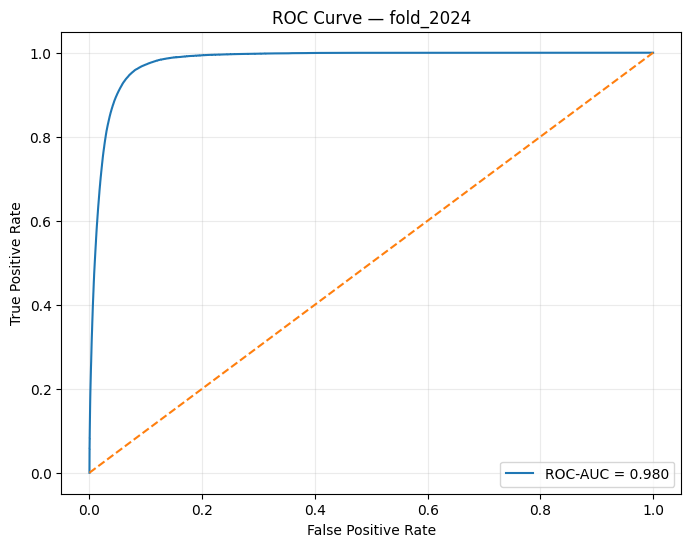

In [12]:
# ROC curve by validation fold.

for fold, group in predictions.groupby("fold", observed=True):
    fpr, tpr, _ = roc_curve(
        group["actual"],
        group["probability"],
    )

    roc_auc = roc_auc_score(
        group["actual"],
        group["probability"],
    )

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr,
        tpr,
        label=f"ROC-AUC = {roc_auc:.3f}",
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
    )
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {fold}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## Confusion Matrix at Official Threshold 0.50

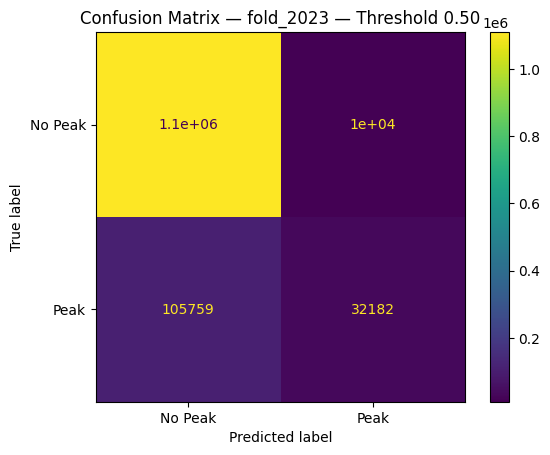

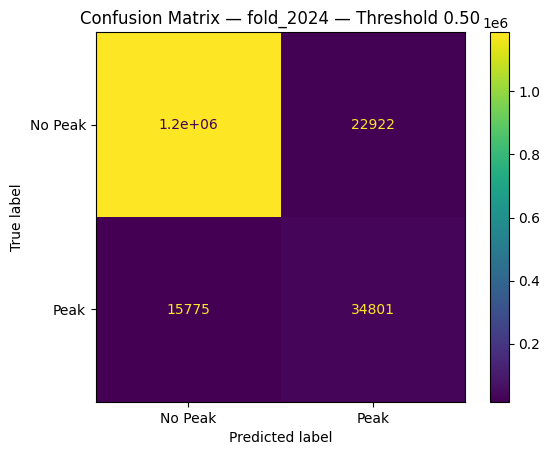

In [13]:
# Confusion matrix by fold at the common comparison threshold.

for fold, group in predictions.groupby("fold", observed=True):
    matrix = confusion_matrix(
        group["actual"],
        group["predicted"],
    )

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["No Peak", "Peak"],
    )

    display_matrix.plot()
    plt.title(f"Confusion Matrix — {fold} — Threshold 0.50")
    plt.show()


## Threshold Diagnostics

,threshold,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,0.05,0.313201,0.916835,0.466903,0.877117,2519424,7.482544,21.903697,0.04464,0.579137,0.941053
1,0.10,0.404453,0.826673,0.543162,0.864113,2519424,7.482544,15.293773,0.04464,0.579137,0.941053
2,0.15,0.459362,0.738809,0.566498,0.834242,2519424,7.482544,12.034457,0.04464,0.579137,0.941053
3,0.20,0.497550,0.661489,0.567926,0.803732,2519424,7.482544,9.947988,0.04464,0.579137,0.941053
4,0.25,0.529662,0.592488,0.559316,0.774968,2519424,7.482544,8.370088,0.04464,0.579137,0.941053
5,0.30,0.561610,0.537962,0.549532,0.752000,2519424,7.482544,7.167472,0.04464,0.579137,0.941053
6,0.35,0.594054,0.493064,0.538868,0.732907,2519424,7.482544,6.210507,0.04464,0.579137,0.941053
7,0.40,0.622288,0.448320,0.521170,0.713156,2519424,7.482544,5.390716,0.04464,0.579137,0.941053
8,0.45,0.646981,0.401730,0.495679,0.692001,2519424,7.482544,4.646141,0.04464,0.579137,0.941053
9,0.50,0.669067,0.355315,0.464143,0.670551,2519424,7.482544,3.973686,0.04464,0.579137,0.941053


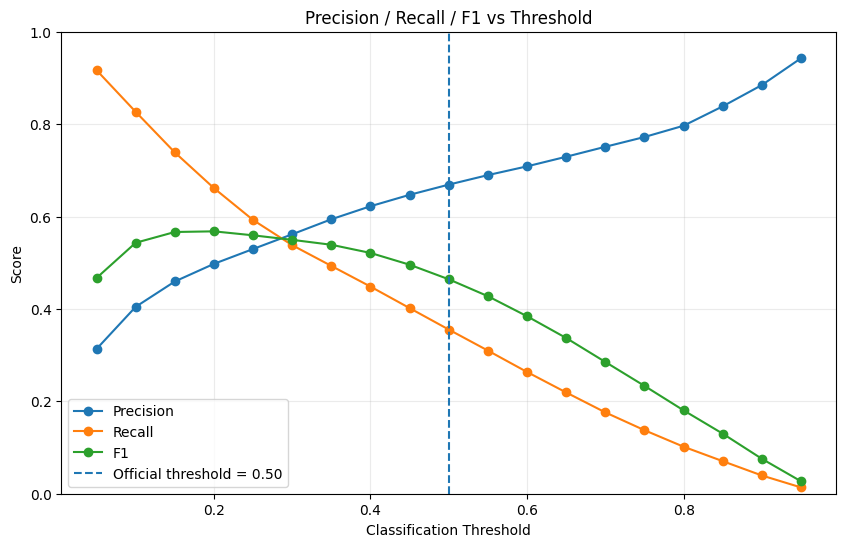

In [14]:
# The threshold sweep is diagnostic only.
# It does not replace the official 0.50 comparison threshold.

display(threshold_analysis)

plt.figure(figsize=(10, 6))
plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["precision"],
    marker="o",
    label="Precision",
)
plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["recall"],
    marker="o",
    label="Recall",
)
plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["f1"],
    marker="o",
    label="F1",
)
plt.axvline(
    0.50,
    linestyle="--",
    label="Official threshold = 0.50",
)
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Class Balance

,fold,horizon,observations,actual_peaks,actual_peak_rate_pct
0,fold_2023,1,52416,5743,10.956578
1,fold_2023,2,52416,5743,10.956578
2,fold_2023,3,52416,5743,10.956578
3,fold_2023,4,52416,5743,10.956578
4,fold_2023,5,52416,5743,10.956578
5,fold_2023,6,52416,5743,10.956578
6,fold_2023,7,52416,5743,10.956578
7,fold_2023,8,52416,5743,10.956578
8,fold_2023,9,52416,5743,10.956578
9,fold_2023,10,52416,5743,10.956578


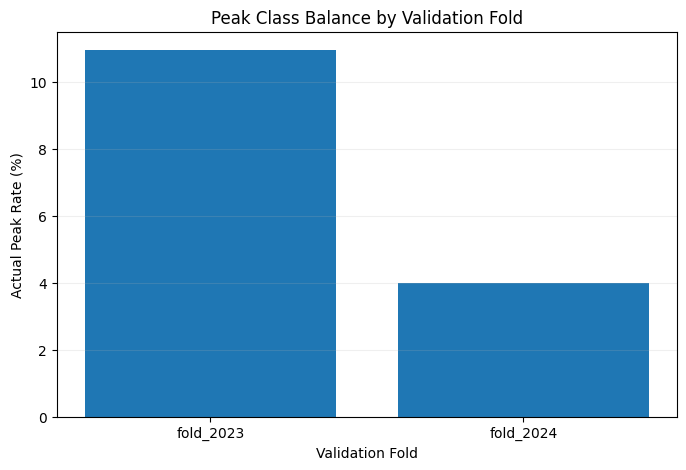

In [15]:
# Actual Peak prevalence by fold and horizon.

display(class_balance)

fold_balance = (
    predictions.groupby("fold", observed=True)["actual"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 5))
plt.bar(
    fold_balance.index.astype(str),
    fold_balance.values,
)
plt.xlabel("Validation Fold")
plt.ylabel("Actual Peak Rate (%)")
plt.title("Peak Class Balance by Validation Fold")
plt.grid(axis="y", alpha=0.2)
plt.show()


## PR-AUC by Forecast Horizon

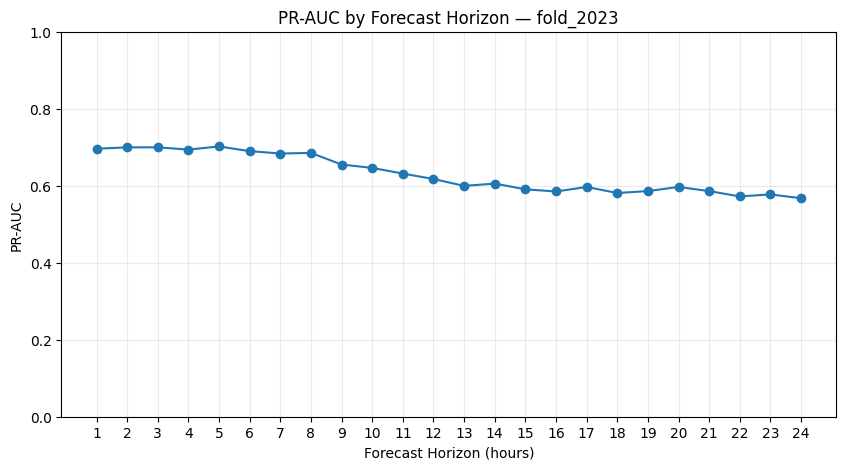

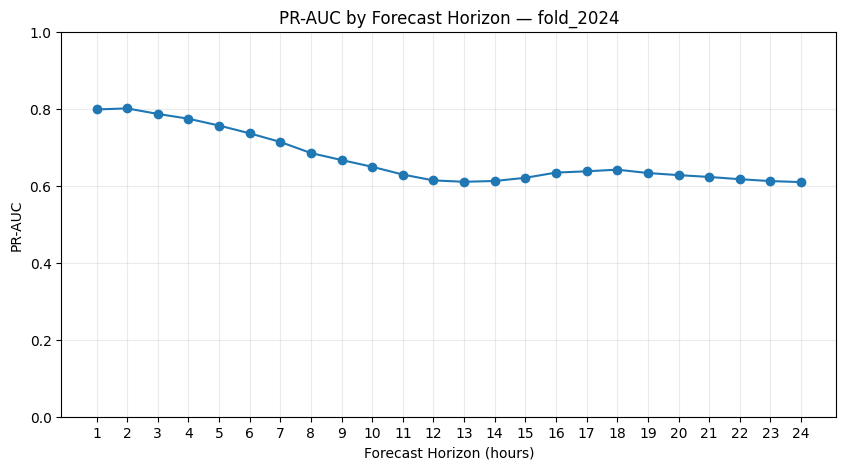

In [16]:
for fold, group in horizon_metrics.groupby("fold", observed=True):
    group = group.sort_values("horizon")

    plt.figure(figsize=(10, 5))
    plt.plot(
        group["horizon"],
        group["pr_auc"],
        marker="o",
    )
    plt.xlabel("Forecast Horizon (hours)")
    plt.ylabel("PR-AUC")
    plt.title(f"PR-AUC by Forecast Horizon — {fold}")
    plt.xticks(range(1, 25))
    plt.ylim(0, 1)
    plt.grid(alpha=0.25)
    plt.show()


## Peak Rate and False Negative Rate by FSA

,fold,fsa,peak_rate_pct
0,fold_2023,L4T,1.900183
1,fold_2023,M5R,1.968864
2,fold_2023,M5S,1.579670
3,fold_2023,M6G,5.574634
4,fold_2023,M9R,3.363954
5,fold_2023,M9W,51.404151
6,fold_2024,L4T,2.796804
7,fold_2024,M5R,1.678082
8,fold_2024,M5S,1.358447
9,fold_2024,M6G,3.641553


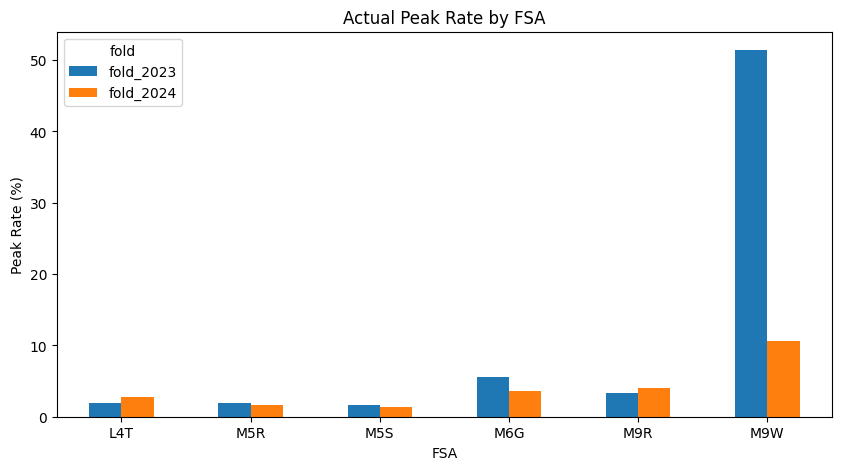

In [17]:
# Peak prevalence by FSA and fold.

fsa_peak_rate = (
    predictions
    .groupby(["fold", "fsa"], observed=True)["actual"]
    .mean()
    .mul(100)
    .reset_index(name="peak_rate_pct")
)

display(fsa_peak_rate)

pivot_peak_rate = fsa_peak_rate.pivot(
    index="fsa",
    columns="fold",
    values="peak_rate_pct",
)

pivot_peak_rate.plot(
    kind="bar",
    figsize=(10, 5),
)
plt.xlabel("FSA")
plt.ylabel("Peak Rate (%)")
plt.title("Actual Peak Rate by FSA")
plt.xticks(rotation=0)
plt.show()


,fold,fsa,actual_peaks,missed_peaks,missed_peak_rate_pct
0,fold_2023,L4T,3984,2136,53.614458
1,fold_2023,M5R,4128,1639,39.704457
2,fold_2023,M5S,3312,1139,34.390097
3,fold_2023,M6G,11688,7472,63.928816
4,fold_2023,M9R,7053,4189,59.393166
5,fold_2023,M9W,107776,89184,82.749406
6,fold_2024,L4T,5880,1650,28.061224
7,fold_2024,M5R,3528,1188,33.673469
8,fold_2024,M5S,2856,924,32.352941
9,fold_2024,M6G,7656,2115,27.625392


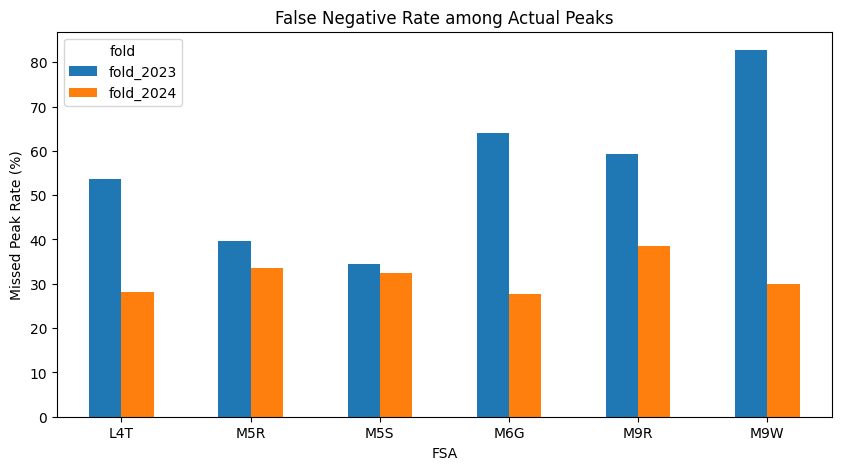

In [18]:
# False Negative Rate among actual Peaks by FSA.

peak_rows = predictions[predictions["actual"] == 1].copy()
peak_rows["missed_peak"] = (
    peak_rows["predicted"] == 0
).astype("int8")

missed_peak_by_fsa = (
    peak_rows
    .groupby(["fold", "fsa"], observed=True)
    .agg(
        actual_peaks=("actual", "size"),
        missed_peaks=("missed_peak", "sum"),
    )
    .reset_index()
)

missed_peak_by_fsa["missed_peak_rate_pct"] = (
    missed_peak_by_fsa["missed_peaks"]
    / missed_peak_by_fsa["actual_peaks"]
    * 100
)

display(missed_peak_by_fsa)

missed_pivot = missed_peak_by_fsa.pivot(
    index="fsa",
    columns="fold",
    values="missed_peak_rate_pct",
)

missed_pivot.plot(
    kind="bar",
    figsize=(10, 5),
)
plt.xlabel("FSA")
plt.ylabel("Missed Peak Rate (%)")
plt.title("False Negative Rate among Actual Peaks")
plt.xticks(rotation=0)
plt.show()


## Monthly Performance

In [19]:
predictions["month"] = (
    predictions["forecast_origin"]
    .dt.to_period("M")
    .astype(str)
)

monthly_rows = []

for (fold, month), group in predictions.groupby(
    ["fold", "month"],
    observed=True,
):
    actual = group["actual"].to_numpy()
    predicted = group["predicted"].to_numpy()
    probability = group["probability"].to_numpy()

    from sklearn.metrics import (
        average_precision_score,
        f1_score,
        precision_score,
        recall_score,
    )

    monthly_rows.append(
        {
            "fold": fold,
            "month": month,
            "observations": len(group),
            "actual_peak_rate_pct": actual.mean() * 100,
            "precision": precision_score(
                actual, predicted, zero_division=0
            ),
            "recall": recall_score(
                actual, predicted, zero_division=0
            ),
            "f1": f1_score(
                actual, predicted, zero_division=0
            ),
            "pr_auc": (
                average_precision_score(actual, probability)
                if len(np.unique(actual)) == 2
                else np.nan
            ),
        }
    )

monthly_metrics = pd.DataFrame(monthly_rows)
display(monthly_metrics)


,fold,month,observations,actual_peak_rate_pct,precision,recall,f1,pr_auc
0,fold_2023,2023-01,107136,9.340464,0.771782,0.292995,0.424743,0.627124
1,fold_2023,2023-02,96768,11.170015,0.712644,0.258118,0.378973,0.615273
2,fold_2023,2023-03,107136,17.474052,0.674465,0.328027,0.441386,0.614620
3,fold_2023,2023-04,103680,11.009838,0.850829,0.013491,0.026561,0.816029
4,fold_2023,2023-05,107136,11.741151,0.787611,0.127355,0.219257,0.685110
5,fold_2023,2023-06,103680,2.681327,0.344828,0.061151,0.103880,0.217084
6,fold_2023,2023-07,107136,7.707027,0.417829,0.148722,0.219364,0.351062
7,fold_2023,2023-08,107136,2.545363,0.209877,0.031170,0.054278,0.156994
8,fold_2023,2023-09,103680,19.785880,0.844737,0.297309,0.439821,0.758608
9,fold_2023,2023-10,107136,12.914427,0.913978,0.030717,0.059436,0.746177


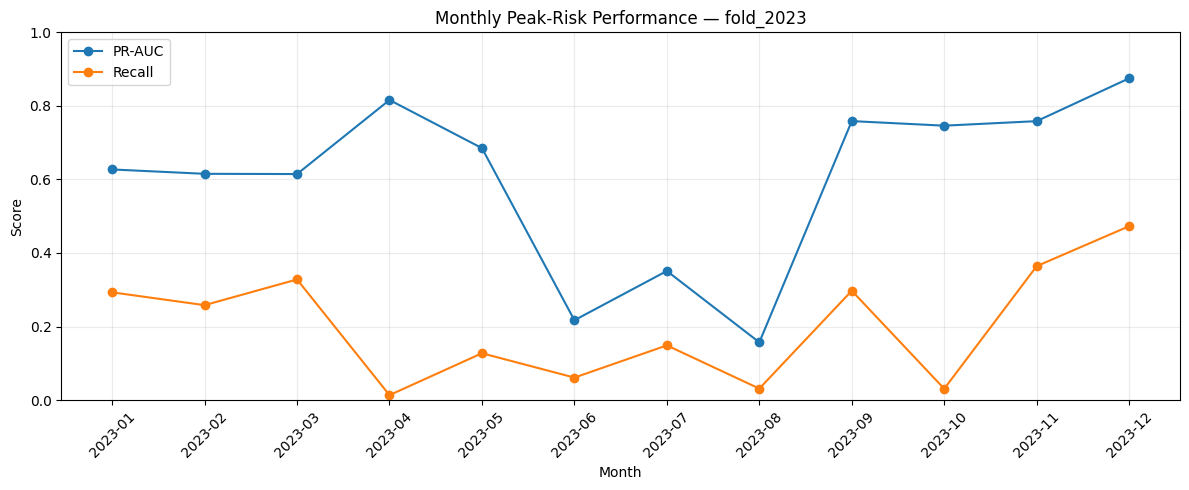

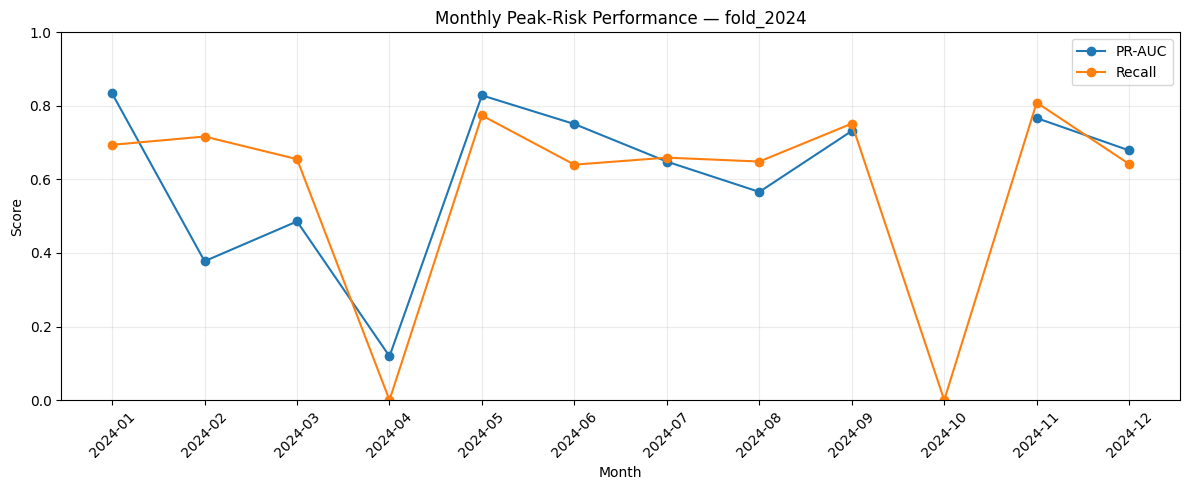

In [20]:
for fold, group in monthly_metrics.groupby("fold", observed=True):
    plt.figure(figsize=(12, 5))
    plt.plot(
        group["month"],
        group["pr_auc"],
        marker="o",
        label="PR-AUC",
    )
    plt.plot(
        group["month"],
        group["recall"],
        marker="o",
        label="Recall",
    )
    plt.xlabel("Month")
    plt.ylabel("Score")
    plt.title(f"Monthly Peak-Risk Performance — {fold}")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## Probability Distribution

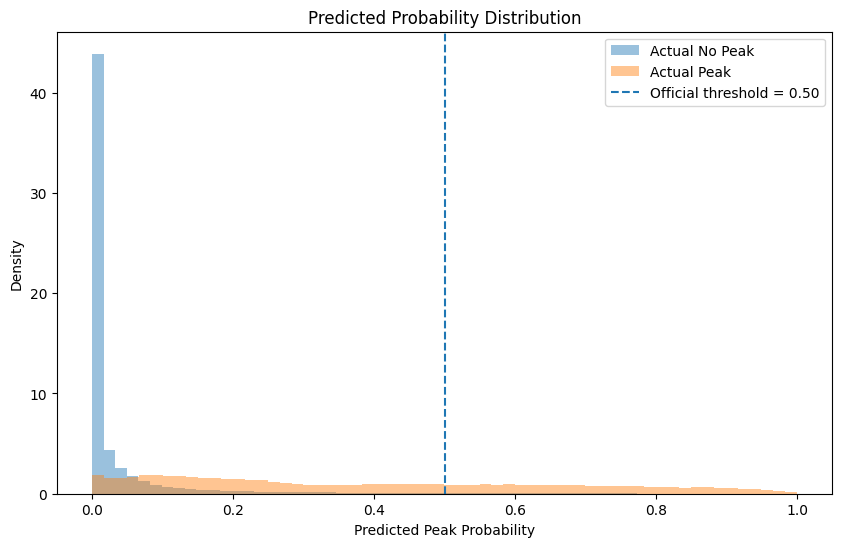

In [21]:
no_peak = predictions.loc[
    predictions["actual"] == 0,
    "probability",
]

peak = predictions.loc[
    predictions["actual"] == 1,
    "probability",
]

plt.figure(figsize=(10, 6))
plt.hist(
    no_peak,
    bins=60,
    density=True,
    alpha=0.45,
    label="Actual No Peak",
)
plt.hist(
    peak,
    bins=60,
    density=True,
    alpha=0.45,
    label="Actual Peak",
)
plt.axvline(
    0.50,
    linestyle="--",
    label="Official threshold = 0.50",
)
plt.xlabel("Predicted Peak Probability")
plt.ylabel("Density")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.show()


## Calibration / Brier Diagnostic

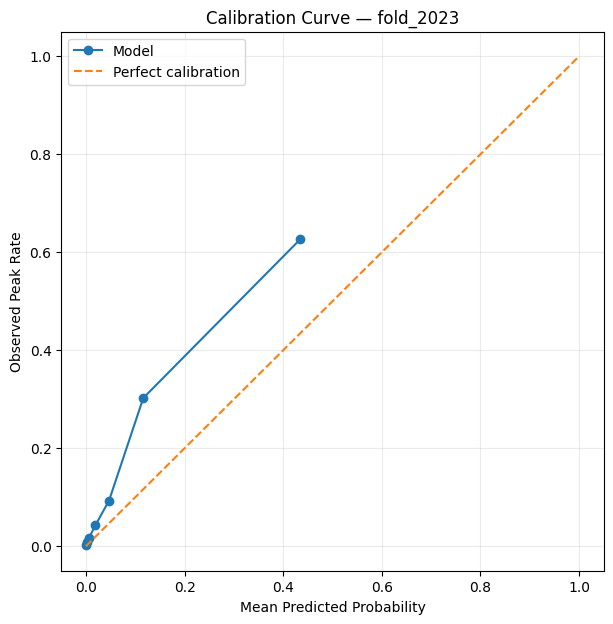

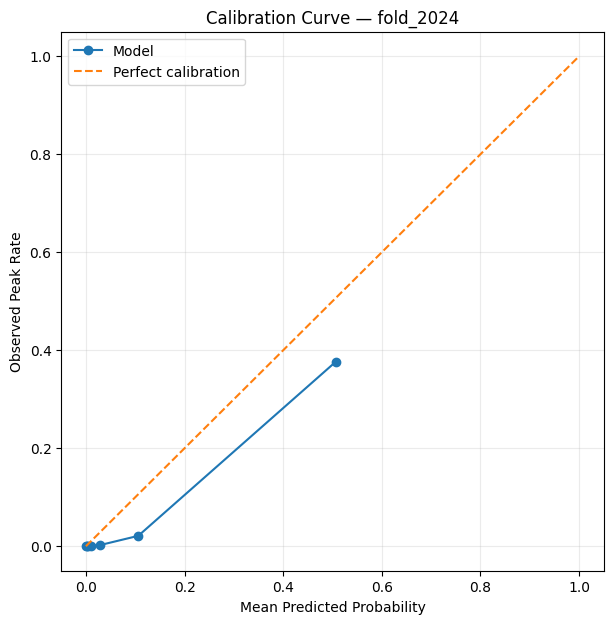

In [22]:
# Reliability curve by fold.
# Calibration and Brier score are supplementary diagnostics, not the common
# model-selection metric.

for fold, group in predictions.groupby("fold", observed=True):
    fraction_of_positives, mean_predicted = calibration_curve(
        group["actual"],
        group["probability"],
        n_bins=10,
        strategy="quantile",
    )

    plt.figure(figsize=(7, 7))
    plt.plot(
        mean_predicted,
        fraction_of_positives,
        marker="o",
        label="Model",
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Peak Rate")
    plt.title(f"Calibration Curve — {fold}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## Actual Peak Detection Timeline

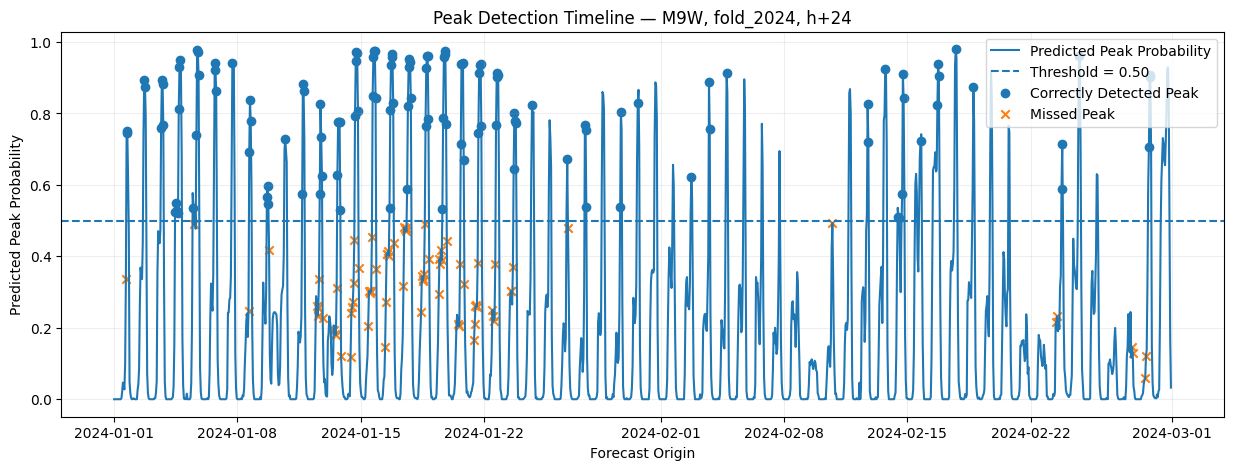

In [23]:
# Representative h+24 M9W timeline.
# Correctly detected and missed Peaks are displayed against predicted risk.

timeline = (
    predictions[
        (predictions["fold"] == "fold_2024")
        & (predictions["fsa"] == "M9W")
        & (predictions["horizon"] == 24)
    ]
    .sort_values("forecast_origin")
    .head(24 * 60)
    .copy()
)

plt.figure(figsize=(15, 5))
plt.plot(
    timeline["forecast_origin"],
    timeline["probability"],
    label="Predicted Peak Probability",
)
plt.axhline(
    0.50,
    linestyle="--",
    label="Threshold = 0.50",
)

correct = timeline[
    (timeline["actual"] == 1)
    & (timeline["predicted"] == 1)
]
missed = timeline[
    (timeline["actual"] == 1)
    & (timeline["predicted"] == 0)
]

plt.scatter(
    correct["forecast_origin"],
    correct["probability"],
    marker="o",
    label="Correctly Detected Peak",
)
plt.scatter(
    missed["forecast_origin"],
    missed["probability"],
    marker="x",
    label="Missed Peak",
)

plt.xlabel("Forecast Origin")
plt.ylabel("Predicted Peak Probability")
plt.title("Peak Detection Timeline — M9W, fold_2024, h+24")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## Feature Importance

,feature,importance
0,target_hour_sin,0.213861
1,origin__Temp (°C),0.166765
2,target_hour,0.128846
3,target_lag_24h,0.105389
4,target_hour_cos,0.033682
5,origin_rolling_mean_24h,0.032305
6,target_month_cos,0.032054
7,target_month_sin,0.031851
8,origin_rolling_std_24h,0.029007
9,target_lag_48h,0.023762


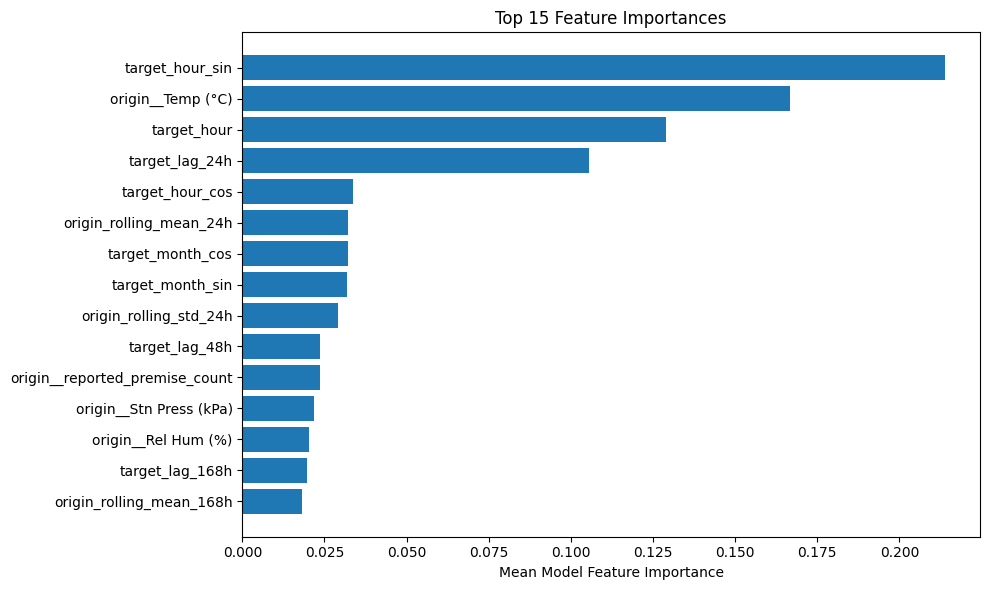

In [24]:
display(feature_importance.head(20))

plot_data = (
    feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["feature"],
    plot_data["importance"],
)
plt.xlabel("Mean Model Feature Importance")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()


## Additional diagnostic 1 - Global metrics with and without M9W-2023

In [25]:
# ============================================================
# Additional diagnostic 1
# Global metrics with and without M9W-2023
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
)

def evaluate_subset(frame, label):

    y_true = frame["actual"].astype(int)
    y_pred = frame["predicted"].astype(int)
    y_prob = frame["probability"].astype(float)

    return {
        "segment": label,
        "observations": len(frame),
        "peak_rate_pct": y_true.mean() * 100,
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "pr_auc": (
            average_precision_score(
                y_true,
                y_prob,
            )
            if y_true.nunique() == 2
            else np.nan
        ),
        "roc_auc": (
            roc_auc_score(
                y_true,
                y_prob,
            )
            if y_true.nunique() == 2
            else np.nan
        ),
        "brier_score": brier_score_loss(
            y_true,
            y_prob,
        ),
    }


m9w_2023_mask = (
    (predictions["fold"] == "fold_2023")
    &
    (predictions["fsa"] == "M9W")
)

comparison = pd.DataFrame(
    [
        evaluate_subset(
            predictions,
            "All validation data",
        ),
        evaluate_subset(
            predictions.loc[~m9w_2023_mask],
            "Excluding M9W-2023",
        ),
        evaluate_subset(
            predictions.loc[m9w_2023_mask],
            "M9W-2023 only",
        ),
    ]
)

display(comparison)

,segment,observations,peak_rate_pct,precision,recall,f1,balanced_accuracy,pr_auc,roc_auc,brier_score
0,All validation data,2519424,7.482544,0.669067,0.355315,0.464143,0.670551,0.579137,0.941053,0.044640
1,Excluding M9W-2023,2309760,3.495645,0.595245,0.599336,0.597283,0.792287,0.620694,0.972378,0.021261
2,M9W-2023 only,209664,51.404151,0.987990,0.172506,0.293726,0.585144,0.927679,0.925991,0.302187


In [26]:
# ============================================================
# Additional diagnostic 2
# Macro-average metrics across FSA
# ============================================================

macro_fsa = (
    fsa_metrics
    .groupby(
        "fold",
        observed=True,
    )
    .agg(
        macro_precision=("precision", "mean"),
        macro_recall=("recall", "mean"),
        macro_f1=("f1", "mean"),
        macro_pr_auc=("pr_auc", "mean"),
        macro_roc_auc=("roc_auc", "mean"),
        macro_balanced_accuracy=(
            "balanced_accuracy",
            "mean",
        ),
    )
    .reset_index()
)

display(macro_fsa)

,fold,macro_precision,macro_recall,macro_f1,macro_pr_auc,macro_roc_auc,macro_balanced_accuracy
0,fold_2023,0.638514,0.443699,0.472561,0.616870,0.959300,0.717595
1,fold_2024,0.575161,0.683000,0.621825,0.647745,0.980045,0.831827


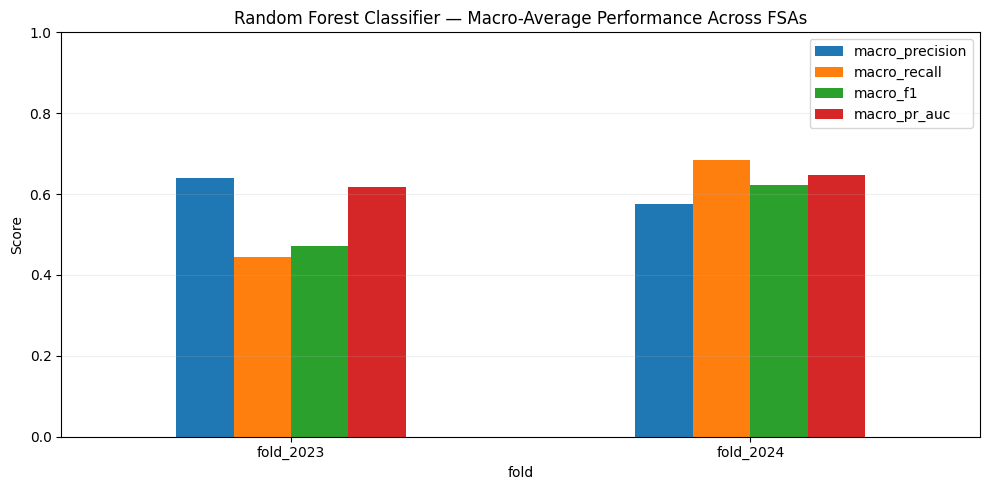

In [27]:
macro_plot = macro_fsa.set_index("fold")[
    [
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "macro_pr_auc",
    ]
]

macro_plot.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.ylabel("Score")
plt.title(
    "Random Forest Classifier — "
    "Macro-Average Performance Across FSAs"
)

plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# Additional diagnostic 3
# Threshold analysis by fold
# ============================================================

threshold_values = np.arange(
    0.05,
    0.96,
    0.05,
)

threshold_fold_rows = []

for fold, group in predictions.groupby(
    "fold",
    observed=True,
):

    y_true = group["actual"].astype(int)
    y_prob = group["probability"].astype(float)

    for threshold in threshold_values:

        y_pred = (
            y_prob >= threshold
        ).astype(int)

        threshold_fold_rows.append(
            {
                "fold": fold,
                "threshold": threshold,
                "precision": precision_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),
                "recall": recall_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),
                "f1": f1_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),
            }
        )

threshold_by_fold = pd.DataFrame(
    threshold_fold_rows
)

display(threshold_by_fold)

,fold,threshold,precision,recall,f1
0,fold_2023,0.05,0.408409,0.889764,0.559845
1,fold_2023,0.10,0.532689,0.771192,0.630127
2,fold_2023,0.15,0.596256,0.657143,0.625221
3,fold_2023,0.20,0.630199,0.559239,0.592602
4,fold_2023,0.25,0.654967,0.474964,0.550628
5,fold_2023,0.30,0.680068,0.411908,0.513062
6,fold_2023,0.35,0.707043,0.364170,0.480733
7,fold_2023,0.40,0.728040,0.318991,0.443613
8,fold_2023,0.45,0.744540,0.275074,0.401728
9,fold_2023,0.50,0.759171,0.233303,0.356919


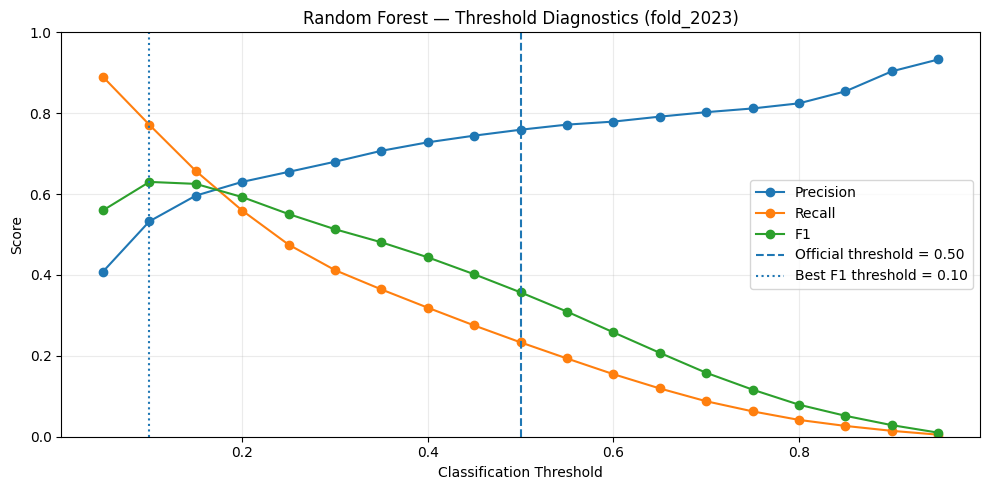

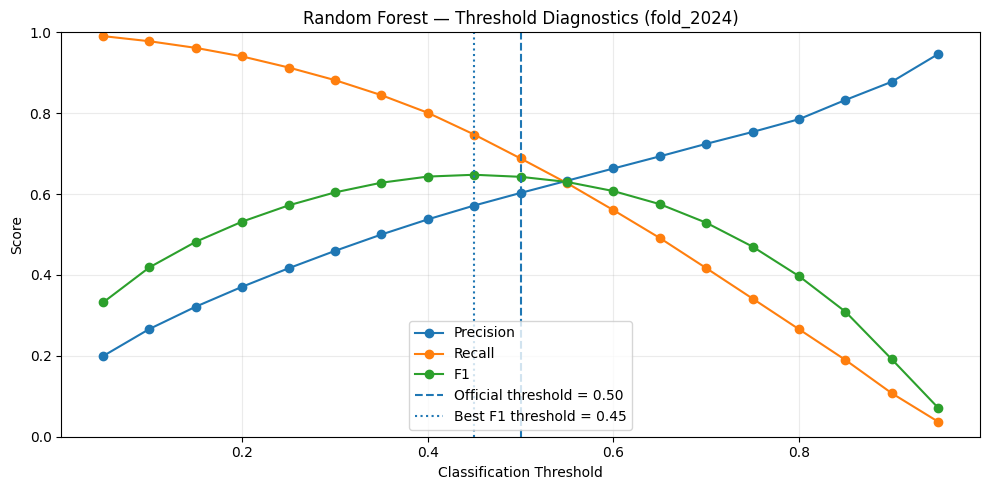

In [29]:
for fold, group in threshold_by_fold.groupby(
    "fold",
    observed=True,
):

    plt.figure(figsize=(10, 5))

    plt.plot(
        group["threshold"],
        group["precision"],
        marker="o",
        label="Precision",
    )

    plt.plot(
        group["threshold"],
        group["recall"],
        marker="o",
        label="Recall",
    )

    plt.plot(
        group["threshold"],
        group["f1"],
        marker="o",
        label="F1",
    )

    plt.axvline(
        0.50,
        linestyle="--",
        label="Official threshold = 0.50",
    )

    best_row = group.loc[
        group["f1"].idxmax()
    ]

    plt.axvline(
        best_row["threshold"],
        linestyle=":",
        label=(
            "Best F1 threshold = "
            f"{best_row['threshold']:.2f}"
        ),
    )

    plt.xlabel("Classification Threshold")
    plt.ylabel("Score")

    plt.title(
        f"Random Forest — Threshold Diagnostics ({fold})"
    )

    plt.ylim(0, 1)

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [30]:
best_threshold_by_fold = (
    threshold_by_fold
    .loc[
        threshold_by_fold
        .groupby("fold")["f1"]
        .idxmax()
    ]
    .sort_values("fold")
    .reset_index(drop=True)
)

display(best_threshold_by_fold)

,fold,threshold,precision,recall,f1
0,fold_2023,0.10,0.532689,0.771192,0.630127
1,fold_2024,0.45,0.571755,0.747173,0.647798
